In [39]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Final
from tqdm import tqdm
from pathlib import Path
import sys
from pprint import pprint
sys.path.append(str(Path(".").absolute().parent))
from src.linear_regression_gd import LinearRegressionGD

In [3]:
INITIAL_LEARNING_RATE: Final[float] = 1e-7
LOSSES: np.ndarray = np.ndarray([])

In [ ]:
learning_rates = np.logspace(np.log10(INITIAL_LEARNING_RATE), np.log10(0.1), 100)

In [40]:
def set_data(seed: int | None = None) -> tuple[np.ndarray, np.ndarray]: 
    """Ge sample from y=3x + 4 + noise"""
    rng = np.random.default_rng(seed)
    m = 100
    X = 2 * rng.random((m, 1))    
    y = 4 + 3 * X.squeeze() + rng.normal(size=m)
    return X, y


def learn(model: LinearRegressionGD, dataset: tuple[np.ndarray, np.ndarray]):
    X, y = dataset
    m, d = X.shape
    model.fit(X, y)
    X_with_intercept = np.column_stack([np.ones(m), X])
    return X_with_intercept, model.loss_history

def learn_many(learning_rates: np.ndarray):
    results = {
        "xs": [],
        "losses": [],
    }
    for lr in tqdm(learning_rates):
        model = LinearRegressionGD(learning_rate=lr, verbose=False)
        xs, losses = learn(model, set_data())
        results["xs"].append(xs)
        results["losses"].append(losses)
    return results



In [42]:
results = learn_many(learning_rates)

 77%|███████▋  | 774/1000 [00:00<00:00, 44215.51it/s]


[np.float64(26.78381228667745), np.float64(19.901786506672728), np.float64(14.823312222725699), np.float64(11.075593217708706), np.float64(8.30977870348768), np.float64(6.268470459545642), np.float64(4.761748125402851), np.float64(3.6494795734108334), np.float64(2.8282686990263626), np.float64(2.221824908121558), np.float64(1.7738572876249674), np.float64(1.4428316020810799), np.float64(1.1981017676983654), np.float64(1.0170554782560217), np.float64(0.8830081182703995), np.float64(0.7836487964566521), np.float64(0.7098937585983451), np.float64(0.6550403834309423), np.float64(0.6141429623138077), np.float64(0.5835521210468012), np.float64(0.5605749842884173), np.float64(0.5432244293460687), np.float64(0.5300340741495722), np.float64(0.5199217668896937), np.float64(0.5120888623879107), np.float64(0.5059459035422375), np.float64(0.5010577856382173), np.float64(0.4971032960037551), np.float64(0.4938452604467652), np.float64(0.49110851586027493), np.float64(0.4887636573307683), np.float64(0

 76%|███████▌  | 758/1000 [00:00<00:00, 42052.33it/s]


[np.float64(27.592062000733478), np.float64(19.197165930922026), np.float64(13.41520603041306), np.float64(9.432707191554638), np.float64(6.689454530399431), np.float64(4.799645470616577), np.float64(3.497589679035812), np.float64(2.600314329682298), np.float64(1.981811532497866), np.float64(1.5553033524142226), np.float64(1.26102828915052), np.float64(1.057830212262463), np.float64(0.91736592677973), np.float64(0.8201161068537737), np.float64(0.7526381518813196), np.float64(0.7056743153333424), np.float64(0.6728488328300467), np.float64(0.6497706753577369), np.float64(0.633415643685725), np.float64(0.6217008362293283), np.float64(0.6131915984192471), np.float64(0.6068997078939506), np.float64(0.6021443909182879), np.float64(0.5984566086814648), np.float64(0.5955131421938563), np.float64(0.5930911985380647), np.float64(0.5910371495294447), np.float64(0.5892450029219818), np.float64(0.5876415761123169), np.float64(0.5861762856442547), np.float64(0.5848141154710704), np.float64(0.5835307

 70%|███████   | 705/1000 [00:00<00:00, 33023.80it/s]


[np.float64(26.834337033808712), np.float64(17.728007314417113), np.float64(11.790857746729525), np.float64(7.919730054460097), np.float64(5.395469002899492), np.float64(3.7492530278999854), np.float64(2.675454449111072), np.float64(1.974832571069285), np.float64(1.5175009580845997), np.float64(1.218785600072181), np.float64(1.0234867199777231), np.float64(0.895618960653257), np.float64(0.8117229569570519), np.float64(0.7565051132182816), np.float64(0.7199951503864255), np.float64(0.6956930954583974), np.float64(0.6793612936867064), np.float64(0.6682369146342254), np.float64(0.6605185804477023), np.float64(0.655031695893356), np.float64(0.6510102750422478), np.float64(0.6479547127558876), np.float64(0.6455390650017625), np.float64(0.643550604246549), np.float64(0.641850415150547), np.float64(0.6403477065516819), np.float64(0.6389830651761257), np.float64(0.637717538512056), np.float64(0.6365255177494762), np.float64(0.6353900980066685), np.float64(0.6343000535161308), np.float64(0.6332

100%|██████████| 100/100 [00:02<00:00, 38.52it/s]

[np.float64(28.03480444608195), np.float64(16.551393439580107), np.float64(9.892178529621718), np.float64(6.029684460535054), np.float64(3.7885528865608507), np.float64(2.4874098477289404), np.float64(1.7312512371053417), np.float64(1.2910856939163802), np.float64(1.0341618707060287), np.float64(0.8835201834539071), np.float64(0.7945443826549415), np.float64(0.7413681630622168), np.float64(0.7089948799162958), np.float64(0.6887292345171961), np.float64(0.6755289556976808), np.float64(0.6664695303444188), np.float64(0.6598541843684568), np.float64(0.6546979246057228), np.float64(0.6504284292150132), np.float64(0.6467126482833178), np.float64(0.6433562804708781), np.float64(0.6402454969744164), np.float64(0.6373131569007182), np.float64(0.6345192206964615), np.float64(0.6318393944290105), np.float64(0.6292585456431029), np.float64(0.6267668854012792), np.float64(0.6243577539526046), np.float64(0.6220263360787182), np.float64(0.6197689154172606), np.float64(0.6175824412674169), np.float64

In [ ]:
def plot_results(results):
    results
    X, y = dataset
    m, d = X.shape
    model.fit(X, y)
    X_with_intercept = np.column_stack([np.ones(m), X])
    theta_closed_form = (
        np.linalg.inv(X_with_intercept.T @ X_with_intercept)
        @ X_with_intercept.T
        @ y
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Plot data and fitted line
    ax1.scatter(X, y, alpha=0.5, label="Data")
    X_plot = np.array([[0], [2]])
    y_pred_gd = model.predict(X_plot)
    ax1.plot(X_plot, y_pred_gd, "r-", linewidth=2, label="Gradient Descent")
    ax1.plot(
        X_plot,
        [theta_closed_form[0], theta_closed_form[0] + 2 * theta_closed_form[1]],
        "g--",
        linewidth=2,
        label="Closed-Form",
    )
    print(model.loss_history[-1])

(100, 2)

In [ ]:
def learn(model: LinearRegressionGD, dataset: tuple[np.ndarray, np.ndarray]):
    X, y = dataset
    m, d = X.shape
    model.fit(X, y)
    X_with_intercept = np.column_stack([np.ones(m), X])
    theta_closed_form = (
        np.linalg.inv(X_with_intercept.T @ X_with_intercept)
        @ X_with_intercept.T
        @ y
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Plot data and fitted line
    ax1.scatter(X, y, alpha=0.5, label="Data")
    X_plot = np.array([[0], [2]])
    y_pred_gd = model.predict(X_plot)
    ax1.plot(X_plot, y_pred_gd, "r-", linewidth=2, label="Gradient Descent")
    ax1.plot(
        X_plot,
        [theta_closed_form[0], theta_closed_form[0] + 2 * theta_closed_form[1]],
        "g--",
        linewidth=2,
        label="Closed-Form",
    )
    print(model.loss_history[-1])

100%|██████████| 10000/10000 [00:00<00:00, 56084.53it/s]


'\nGradient Descent Solution:'
'θ₀ (intercept) = 3.8864'
'θ₁ (slope) = 3.0217'
'\nClosed-Form Solution:'
'θ₀ (intercept) = 3.9224'
'θ₁ (slope) = 2.9909'
0.5218152286411639


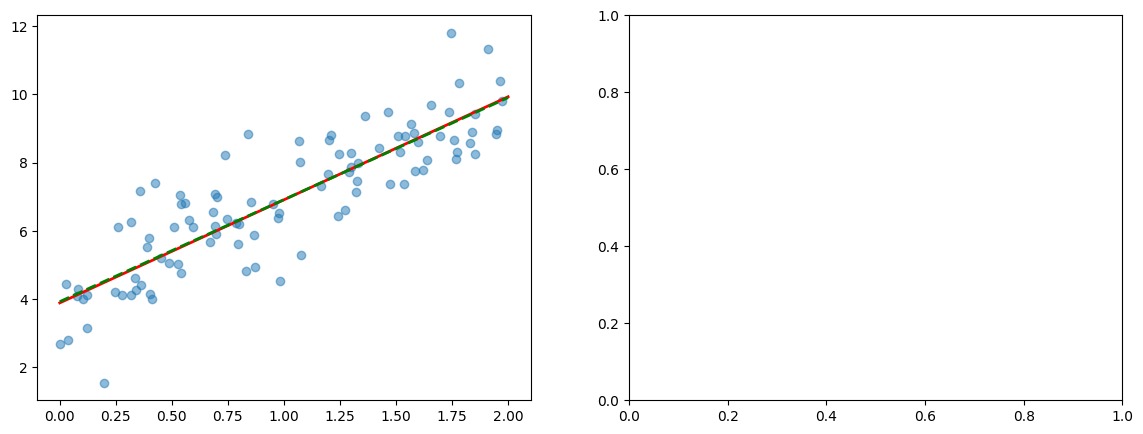

In [36]:
learn(
    LinearRegressionGD(learning_rate=0.002, num_iterations=10_000, tolerance=1e-10, verbose=False),
    set_data(301)
)

In [ ]:
current_learning_rate = current_learning_rate ** 2